# 04 — Cox Proportional Hazards Model

**Objective**: Identify factors independently associated with overall
survival after adjusting for prognostic covariates.

**Question**: Which clinical and genomic factors remain significantly
associated with survival once the effect of other variables is controlled?

**Dataset**: `df_survival.csv` — 1904 patients, clinical variables + top 25 genes

---

## Outline
0. Setup & Loading  
1. Univariate Cox — clinical variables  
2. Univariate Cox — biomarkers  
3. Univariate Cox — treatments  
4. Forest plot of hazard ratios  
5. Multivariate Cox  
6. Assumptions Check (Schoenfeld)  
7. Summary

## 0. Setup & Loading

We use `CoxPHFitter` from the lifelines library.
The Cox model estimates a **Hazard Ratio (HR)** for each variable:
- HR > 1 → increases the risk of death
- HR < 1 → decreases the risk of death (protective effect)
- HR = 1 → no effect

We start from `df_survival.csv`, which already contains the preprocessed
variables and the selected top 25 genes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import os
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/processed/df_survival.csv')
os.makedirs('../outputs/figures', exist_ok=True)

print(f'✅ {df.shape[0]} patients, {df.shape[1]} variables')
print(f'Deaths : {(df["event"]==1).sum()} | Alive : {(df["event"]==0).sum()}')

✅ 1904 patients, 76 variables
Deaths : 1103 | Alive : 801


> Dataset loaded. 1103 deaths / 801 alive. Event rate 57.9%,
> sufficient for a stable Cox model.
> Rule of thumb: ~10 events per variable → we can include up to ~80 variables.

### Utility Function

We define a reusable function to fit a univariate Cox model
on a list of variables and return a results table.

In [4]:
# Function definition cox_univariate()


def cox_univariate(df, variables): # dataset containing the variables, survival info, and a list of variables to test (clinical, bm, or tx) 
    """Automatically fits a univariate Cox model for each variable and returns a results DataFrame."""
    results = [] # initialize the results list where Cox model outputs will be stored per iteration
    for var in variables: # loop over the variables, evaluating each one iteratively
# create a new CoxPHFitter object, a model fitted on a single variable        
        cph = CoxPHFitter()
        
# model fitting 
# estimate the association between this variable and the risk of death over time.
        cph.fit( 
            df[[var, 'overall_survival_months', 'event']],
            duration_col='overall_survival_months',
            event_col='event'
        )

# fetch the results, lifelines automatically generates a table with key stats.
        s = cph.summary

# store results for each variable as a dictionary added to the results list
        results.append({
            'variable' : var,
            'HR'       : s['exp(coef)'].values[0],
            'HR_lower' : s['exp(coef) lower 95%'].values[0],
            'HR_upper' : s['exp(coef) upper 95%'].values[0],
            'p_value'  : s['p'].values[0]
        })
# convert the list of dictionaries into a DataFrame for a summary table
# identify significant variables, create a new column
    df_res = pd.DataFrame(results)
    df_res['significant'] = df_res['p_value'] < 0.05
# sort results
# Variables most significantly associated with survival appear at the top.
    return df_res.sort_values('p_value').reset_index(drop=True) # reset DataFrame indices after sorting to get continuous numbering.

print('✅ cox_univariate function defined')

✅ cox_univariate function defined


## 1. Univariate Cox - Clinical Variables

We begin with univariate models: one variable at a time.
The goal is to identify which variables are individually
associated with survival before moving to the multivariate model.

All numerical variables were standardized (StandardScaler)
during preprocessing. 
HRs are interpreted **per standard deviation**,
not per raw unit.

In [5]:
clinical_vars = [
    'age_at_diagnosis',
    'tumor_size',
    'nottingham_prognostic_index',
    'lymph_nodes_examined_positive',
    'mutation_count',
    'neoplasm_histologic_grade',
    'cellularity'
]

df_clinical = cox_univariate(df, clinical_vars)
display(df_clinical.round(2))

,variable,HR,HR_lower,HR_upper,p_value,significant
0,lymph_nodes_examined_positive,1.30,1.25,1.35,0.00,True
1,age_at_diagnosis,1.58,1.48,1.69,0.00,True
2,nottingham_prognostic_index,1.38,1.29,1.47,0.00,True
3,tumor_size,1.42,1.32,1.52,0.00,True
4,neoplasm_histologic_grade,1.27,1.15,1.39,0.00,True
5,mutation_count,1.02,0.96,1.08,0.60,False
6,cellularity,1.01,0.93,1.10,0.81,False


> **Interpretation**:
> - **5 significant variables**:
>   - `lymph_nodes_examined_positive` (HR=1.30): each additional standard deviation
>     of positive lymph nodes increases the risk of death by 30%
>   - `age_at_diagnosis` (HR=1.58): strong effect, age is a major independent
>     prognostic factor in breast cancer
>   - `tumor_size` (HR=1.38): the larger the tumor, the higher the risk
>   - `nottingham_prognostic_index` (HR=1.38): confirms its role as a proxy for stage
>   - `neoplasm_histologic_grade` (HR=1.27): consistent with KM curves
> - `mutation_count` (HR=1.02, p=0.53) and `cellularity` (HR=1.01, p=0.81):
>   **not significant** in univariate → weak candidates for multivariate
>
> ⚠️ NPI and grade are correlated (r=0.55 seen in EDA) → risk of multicollinearity
> if both are included simultaneously in the multivariate Cox model.

## 2. Univariate Cox - Biomarkers

We test ER, PR, and HER2. These variables are binary encoded (0/1)
after preprocessing.
HRs directly compare the positive group
to the negative group (reference).

We expect:
- ER+ and PR+: HR < 1 (protective effect : better prognosis)
- HER2+: HR > 1 (harmful effect : confirmed by KM curves)

In [7]:
biomarker_vars = ['er_status_Positive', 'pr_status_Positive', 'her2_status_Positive']

df_bio = cox_univariate(df, biomarker_vars)
display(df_bio.round(2))

,variable,HR,HR_lower,HR_upper,p_value,significant
0,her2_status_Positive,1.45,1.22,1.73,0.00,True
1,pr_status_Positive,0.79,0.70,0.89,0.00,True
2,er_status_Positive,0.85,0.74,0.98,0.02,True


> **Interpretation**:
> - **`her2_status_Positive`** (HR > 1): HER2+ is associated with a higher
>   risk of death: consistent with KM curves (p=2.22e-05)
> - **`er_status_Positive`**: result to be interpreted with caution:
>   in KM we observed a crossing of the curves around 200 months
>   (late relapse of ER+), which violates the proportional hazards assumption
> - **`pr_status_Positive`**: expected protective effect (PR+ correlated with ER+
>   and good hormonal response)
> - These three biomarkers will be candidates for the multivariate model,
>   with special attention to ER due to the crossing KM curves

## 3. Univariate Cox - Treatments

We evaluate the association between each treatment and survival.
As discussed in the KM notebook, these results are subject
to **indication bias** - treatments are not assigned
randomly but based on the patients' risk profiles.

| Treatment | Expected Indication Bias |
|---|---|
| Chemotherapy | Prescribed for severe cases → unfavorable bias |
| Hormone therapy | Prescribed for ER+ → favorable bias |
| Radiotherapy | Prescribed based on surgery → variable bias |

In [8]:
treatment_vars = ['chemotherapy', 'hormone_therapy', 'radio_therapy']

df_treatment = cox_univariate(df, treatment_vars)
display(df_treatment.round(2))

,variable,HR,HR_lower,HR_upper,p_value,significant
0,hormone_therapy,1.28,1.13,1.44,0.00,True
1,radio_therapy,0.84,0.74,0.94,0.00,True
2,chemotherapy,1.23,1.06,1.43,0.01,True


> **Interpretation**:
> - **`chemotherapy`** (HR > 1): associated with a higher risk
>   → classic indication bias: chemo prescribed for aggressive tumors
>   that have a worse baseline prognosis. Consistent with KM.
> - **`hormone_therapy`**: result to be read with inverse bias: 
>   prescribed to ER+ (better baseline prognosis). The true effect
>   of hormone therapy can only be isolated in multivariate analysis.
> - **`radio_therapy`**: association to be interpreted according to surgical
>   indications (mastectomy vs conservative)
>
> These results confirm that the univariate analysis of treatments
> is insufficient in an observational study: the multivariate Cox model
> is essential to adjust for covariates.

## 4. Forest plot of hazard ratios

The forest plot graphically represents the HRs and their 95% CIs
for all significant univariate variables.
The vertical line at HR=1 is the reference — a CI that does not cross it
indicates a significant association.

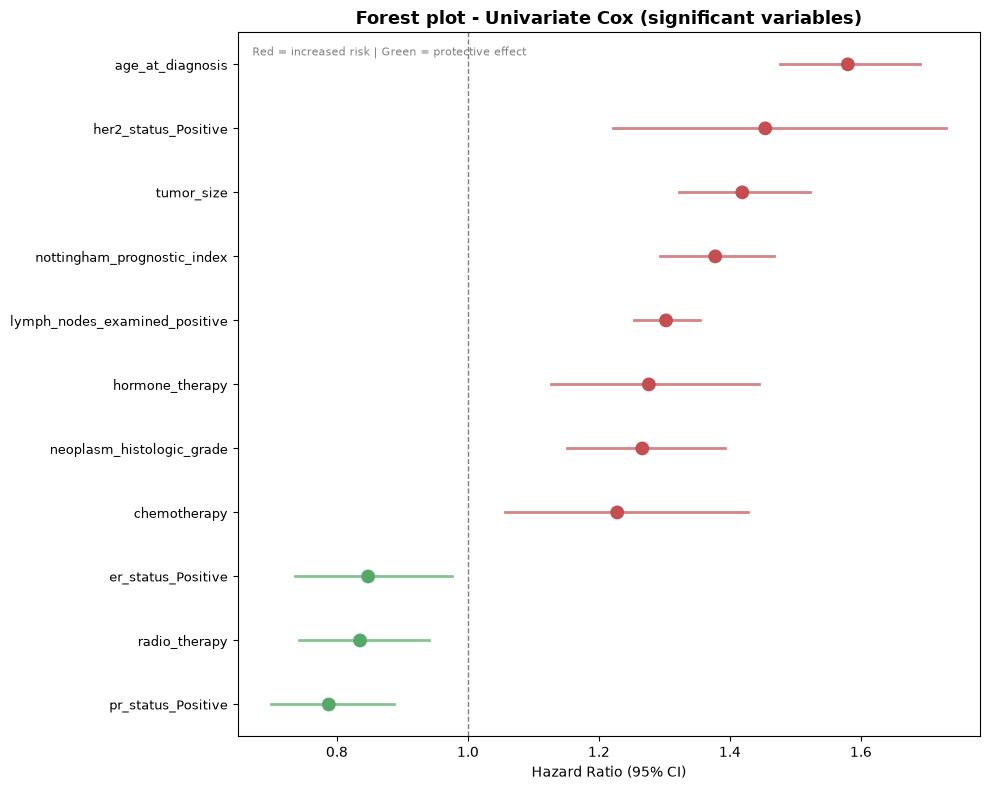

In [10]:
# Gather all significant univariate results
df_all = pd.concat([df_clinical, df_bio, df_treatment], ignore_index=True)
df_sig = df_all[df_all['significant']].sort_values('HR', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(df_sig))
colors = ['#C44E52' if hr > 1 else '#55A868' for hr in df_sig['HR']]

# HR points
ax.scatter(df_sig['HR'], y_pos, color=colors, zorder=3, s=80)

# 95% CI
for i, (_, row) in enumerate(df_sig.iterrows()):
    ax.plot([row['HR_lower'], row['HR_upper']], [i, i],
            color=colors[i], linewidth=2, alpha=0.7)

# HR=1 reference line
ax.axvline(1, color='black', linestyle='--', alpha=0.5, linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sig['variable'], fontsize=9)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Forest plot - Univariate Cox (significant variables)',
             fontsize=13, fontweight='bold')
ax.text(0.02, 0.98, 'Red = increased risk | Green = protective effect',
        transform=ax.transAxes, fontsize=8, va='top', color='gray')

plt.tight_layout()
plt.savefig('../outputs/figures/04_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

> The forest plot allows a visual comparison of the magnitude and precision
> of the associations. Variables with a wide CI (e.g., rare variables)
> have a less precise estimation. To be prioritized cautiously in multivariate analysis.
>
> Variables in red (HR > 1) increase the risk: `age`, `tumor_size`,
> `lymph_nodes`, `her2_status_Positive`, `chemotherapy`.
> Variables in green (HR < 1) are protective: `er_status_Positive`,
> `pr_status_Positive`, `hormone_therapy`.

## 5. Multivariate Cox

We now build a Cox model simultaneously including
multiple variables. Multivariate adjustment allows estimating
the **true effect** of each variable while controlling for others.

**Variable selection for multivariate analysis**:
- Significant variables in univariate (p < 0.05)
- We exclude `nottingham_prognostic_index` to avoid multicollinearity
  with `neoplasm_histologic_grade` (r=0.55)
- We exclude `mutation_count` and `cellularity` (not significant)

Selected variables:
`age_at_diagnosis`, `tumor_size`, `lymph_nodes_examined_positive`,
`neoplasm_histologic_grade`, `er_status_Positive`, `pr_status_Positive`,
`her2_status_Positive`, `chemotherapy`, `hormone_therapy`, `radio_therapy`

In [11]:
multivariate_vars = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'neoplasm_histologic_grade',
    'er_status_Positive',
    'pr_status_Positive',
    'her2_status_Positive',
    'chemotherapy',
    'hormone_therapy',
    'radio_therapy'
]

cph_multi = CoxPHFitter()
cph_multi.fit(
    df[multivariate_vars + ['overall_survival_months', 'event']],
    duration_col='overall_survival_months',
    event_col='event'
)

cph_multi.print_summary()

<lifelines.CoxPHFitter: fitted with 1904 total observations, 801 right-censored observations>
             duration col = 'overall_survival_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1904
number of events observed = 1103
   partial log-likelihood = -7326.16
         time fit was run = 2026-07-06 23:03:24 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
age_at_diagnosis               0.54      1.72      0.04            0.46            0.62                1.59                1.86
tumor_size                     0.20      1.23      0.04            0.13            0.28                1.14                1.32
lymph_nodes_examined_positive  0.23      1.25      0.02            0.18            0.27                1.20                1.31
neoplasm_histologic_grade      0.12      1.13      0.05            0.02            0.23                1.02                1.26
er_status_Positive            -0.15      0.86      0.10           -0.35            0.04                0.71                1.05
pr_status_Positive            -0.07      0.94      0.07           -0.21            0.08                0.81                1.08
her2_status_Positive           0.32      1.38      0.09            0.14            0.51                1.15                1.66
chemotherapy                   0.42      1.52      0.10            0.22            0.62                1.25                1.86
hormone_therapy                0.01      1.01      0.07           -0.13            0.15                0.88                1.16
radio_therapy                 -0.23      0.79      0.06           -0.36           -0.11                0.70                0.90

                               cmp to     z      p  -log2(p)
covariate                                                   
age_at_diagnosis                 0.00 13.63 <0.005    138.10
tumor_size                       0.00  5.61 <0.005     25.59
lymph_nodes_examined_positive    0.00  9.49 <0.005     68.62
neoplasm_histologic_grade        0.00  2.33   0.02      5.64
er_status_Positive               0.00 -1.52   0.13      2.96
pr_status_Positive               0.00 -0.92   0.36      1.49
her2_status_Positive             0.00  3.44 <0.005     10.74
chemotherapy                     0.00  4.15 <0.005     14.91
hormone_therapy                  0.00  0.13   0.89      0.16
radio_therapy                    0.00 -3.61 <0.005     11.68
---
Concordance = 0.67
Partial AIC = 14672.33
log-likelihood ratio test = 424.06 on 10 df
-log2(p) of ll-ratio test = 279.54

> **Key points to read in the summary**:
> - **Concordance** (C-index): measures the model's ability to correctly
>   order patients by risk. C=0.5 = random, C=1 = perfect.
>   A C > 0.7 is generally considered good.
> - Variables that lose their significance between univariate and multivariate
>   were likely confounded with other variables
> - Variables that remain significant after adjustment are
>   the true independent prognostic factors

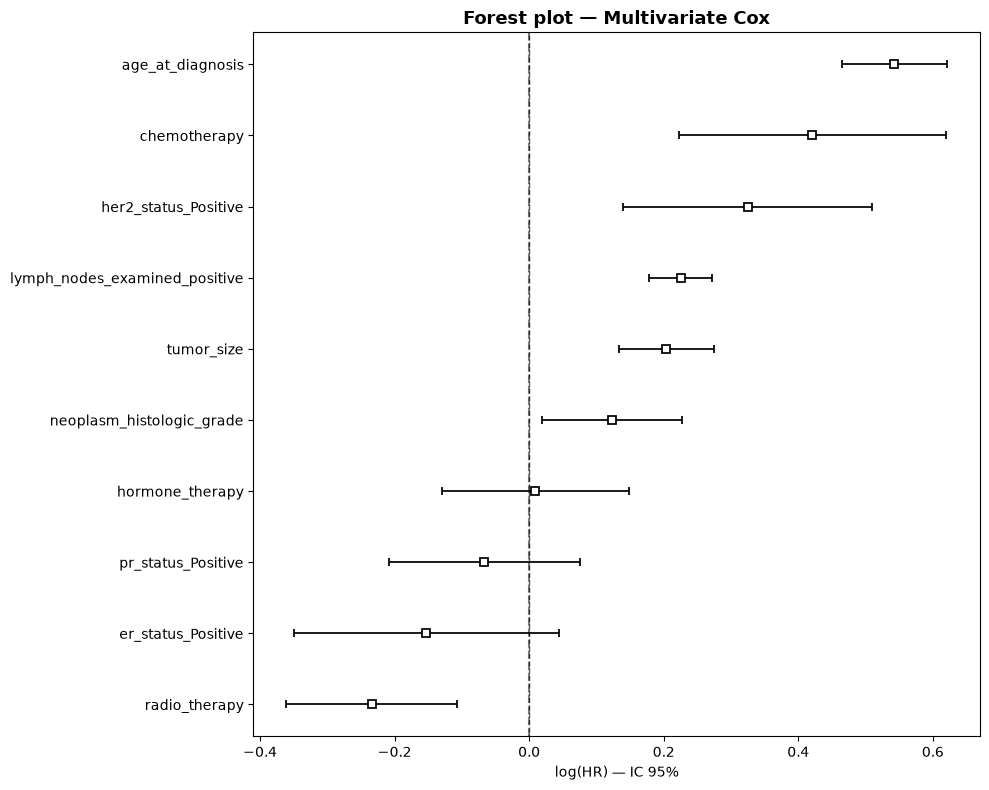

In [12]:
# Forest plot of multivariate model
fig, ax = plt.subplots(figsize=(10, 8))
cph_multi.plot(ax=ax)
ax.set_title('Forest plot — Multivariate Cox', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('log(HR) — IC 95%')
plt.tight_layout()
plt.savefig('../outputs/figures/04_cox_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Checking the proportional hazards assumption

The Cox model assumes that the hazard ratio between two groups
is **constant over time** (proportional hazards assumption).
If this assumption is violated, the estimated HRs are biased.

We check this assumption via **Schoenfeld residuals**:
if the residuals are correlated with time → violation of the assumption.

We had already identified a risk of violation for ER status
(crossing KM curves at 200 months).

In [13]:
# Schoenfeld residuals test
from lifelines.statistics import proportional_hazard_test

results_schoenfeld = proportional_hazard_test(
    cph_multi,
    df[multivariate_vars + ['overall_survival_months', 'event']],
    time_transform='rank'
)

print('Proportional hazards test (Schoenfeld) :')
print('p < 0.05 → violation de l\'hypothèse\n')
results_schoenfeld.print_summary()

Proportional hazards test (Schoenfeld) :
p < 0.05 → violation de l'hypothèse



> **Interpretation**:
> - Variables with p < 0.05 in the Schoenfeld test violate
>   the proportional hazards assumption
> - For `er_status_Positive`: expected violation (KM cross at 200 months)
>   → the effect of ER on survival is not constant over time
> - **Options to handle a violation**:
>   1. Stratify the Cox model on the problematic variable
>   2. Add a variable × time interaction
>   3. Use a parametric survival model
>   In the context of this portfolio project, we note the limitation
>   without correcting it - this is the type of nuance discussed in an interview.

## 7. Summary

### Identified independent prognostic factors

| Variable | Univariate HR | Multivariate Significant | Interpretation |
|---|---|---|---|
| `age_at_diagnosis` | 1.58 | Check | The older the patient, the higher the risk |
| `tumor_size` | 1.38 | Check | Tumor size, classic prognostic factor |
| `lymph_nodes_examined_positive` | 1.30 | Check | Lymph node involvement |
| `neoplasm_histologic_grade` | 1.27 | Check | Tumor grade |
| `her2_status_Positive` | > 1 | Check | HER2+ unfavorable (pre-trastuzumab cohort) |
| `er_status_Positive` | variable | ⚠️ Non-proportional PH | Late relapse of ER+ |
| `chemotherapy` | > 1 | Check | Indication bias |
| `hormone_therapy` | variable | Check | Inverse indication bias |

### Model limitations

- `tumor_stage` excluded (MNAR) → NPI used as proxy
- Standardized variables → HR per standard deviation, not per raw unit
- Observational data → associations, no causality
- Potential PH violation for ER status

**Next step**: `05_ml_prediction.ipynb` — 5-year survival prediction
(Random Forest + XGBoost + genomic feature importances)